# Task 3.2 — Text Classification Project (TensorFlow)
**Problem:** classify SMS messages as spam or legitimate ("ham").
**Dataset:** SMS Spam Collection — 5,574 real text messages (4,827 ham / 747 spam), tab-separated, loaded from `data/sms.tsv`.
**Model:** TensorFlow/Keras text classifier (TextVectorization → Embedding → pooling → dense), compared against a classical TF-IDF + Logistic Regression baseline.
**Skill Set Go EduTech — AI/ML Internship, Week 3**

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

keras.utils.set_random_seed(42)
print("TensorFlow:", tf.__version__)

I0000 00:00:1791279633.421768     534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791279635.032100     534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


## 1. Load and inspect the data

In [2]:
df = pd.read_csv('data/sms.tsv', sep='\t', header=None, names=['label', 'text'])
df['y'] = (df['label'] == 'spam').astype(int)
print(df.shape)
print(df['label'].value_counts())
print(f"Spam share: {df['y'].mean():.1%}")
df['length'] = df['text'].str.len()
print("\nMean message length (chars):")
print(df.groupby('label')['length'].mean().round(1))
df.sample(5, random_state=1)[['label', 'text']]

(5572, 3)
label
ham     4825
spam     747
Name: count, dtype: int64
Spam share: 13.4%

Mean message length (chars):
label
ham      71.5
spam    138.7
Name: length, dtype: float64


,label,text
1078,ham,"Yep, by the pretty sculpture"
4028,ham,"Yes, princess. Are you going to make me moan?"
958,ham,Welp apparently he retired
4642,ham,Havent.
4674,ham,I forgot 2 ask ü all smth.. There's a card on ...


**Note on class imbalance:** only ~13% of messages are spam, so a model that always predicts "ham" would score ~87% accuracy while catching zero spam. Accuracy alone is therefore misleading here; the evaluation focuses on **precision, recall and F1 for the spam class**.

## 2. Train/test split (stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'].values, df['y'].values, test_size=0.2, random_state=42, stratify=df['y'].values)
print("Train:", len(X_train), "| Test:", len(X_test))
print("Spam share train/test:", round(y_train.mean(), 3), round(y_test.mean(), 3))
print("Always-predict-ham accuracy on test:", round(1 - y_test.mean(), 4))

Train: 4457 | Test: 1115
Spam share train/test: 0.134 0.134
Always-predict-ham accuracy on test: 0.8664


## 3. Baseline: TF-IDF + Logistic Regression

In [4]:
tfidf = TfidfVectorizer(lowercase=True, max_features=10000)
Xtr_tfidf = tfidf.fit_transform(X_train)
Xte_tfidf = tfidf.transform(X_test)
base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(Xtr_tfidf, y_train)
base_pred = base.predict(Xte_tfidf)

def report(name, y_true, y_pred):
    return {'Model': name,
            'Accuracy': round(accuracy_score(y_true, y_pred), 4),
            'Spam precision': round(precision_score(y_true, y_pred), 4),
            'Spam recall': round(recall_score(y_true, y_pred), 4),
            'Spam F1': round(f1_score(y_true, y_pred), 4)}

base_row = report('TF-IDF + LogReg (baseline)', y_test, base_pred)
base_row

{'Model': 'TF-IDF + LogReg (baseline)',
 'Accuracy': 0.9839,
 'Spam precision': 0.9517,
 'Spam recall': 0.9262,
 'Spam F1': 0.9388}

## 4. TensorFlow text classifier

In [5]:
MAX_TOKENS, SEQ_LEN = 10000, 50

vectorizer = keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode='int', output_sequence_length=SEQ_LEN, standardize='lower_and_strip_punctuation')
vectorizer.adapt(tf.constant(X_train))   # vocabulary learned from TRAINING text only

model = keras.Sequential([
    keras.layers.Input(shape=(), dtype=tf.string),       # raw strings in
    vectorizer,                                            # text -> integer ids
    keras.layers.Embedding(MAX_TOKENS, 32),                # ids -> 32-d vectors
    keras.layers.GlobalAveragePooling1D(),                 # average over the message
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 50)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,545 (1.22 MB)

 Trainable params: 320,545 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Class weights counter the 87/13 imbalance so the model is not rewarded for ignoring spam
n_ham, n_spam = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: len(y_train) / (2 * n_ham), 1: len(y_train) / (2 * n_spam)}
print("Class weights:", {k: round(v, 3) for k, v in class_weight.items()})

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    tf.constant(X_train), y_train.astype('float32'),
    validation_split=0.1, epochs=30, batch_size=32,
    class_weight=class_weight, callbacks=[early_stop], verbose=0)
print("Epochs trained:", len(history.history['loss']))
print("Best val loss:", round(min(history.history['val_loss']), 4))

Class weights: {0: np.float64(0.577), 1: np.float64(3.727)}


Epochs trained: 15
Best val loss: 0.0635


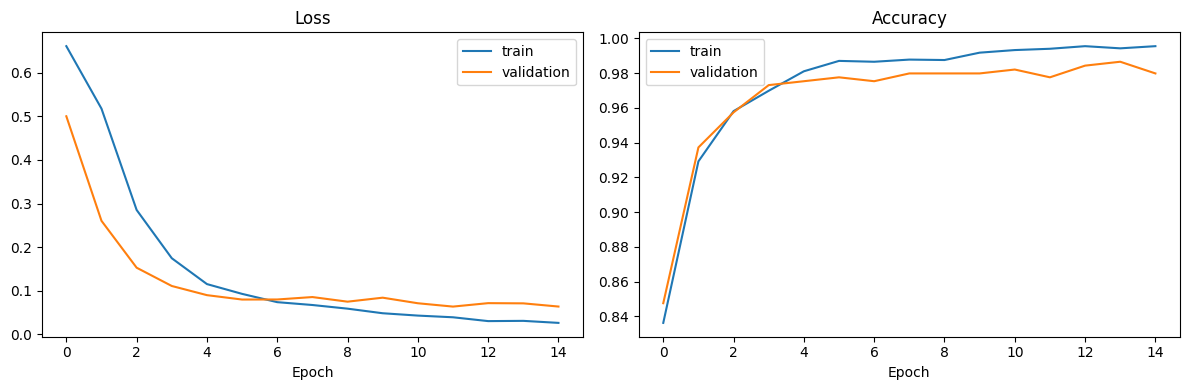

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.savefig('text_training_curves.png', dpi=100); plt.show()

## 5. Evaluation on the held-out test set

In [8]:
probs = model.predict(tf.constant(X_test), verbose=0).ravel()
nn_pred = (probs >= 0.5).astype(int)

nn_row = report('TensorFlow text classifier', y_test, nn_pred)
results = pd.DataFrame([base_row, nn_row])
results.to_csv('model_comparison.csv', index=False)
print(classification_report(y_test, nn_pred, target_names=['ham', 'spam'], digits=4))
results

              precision    recall  f1-score   support

         ham     0.9877    0.9959    0.9918       966
        spam     0.9716    0.9195    0.9448       149

    accuracy                         0.9857      1115
   macro avg     0.9797    0.9577    0.9683      1115
weighted avg     0.9855    0.9857    0.9855      1115



,Model,Accuracy,Spam precision,Spam recall,Spam F1
0,TF-IDF + LogReg (baseline),0.9839,0.9517,0.9262,0.9388
1,TensorFlow text classifier,0.9857,0.9716,0.9195,0.9448


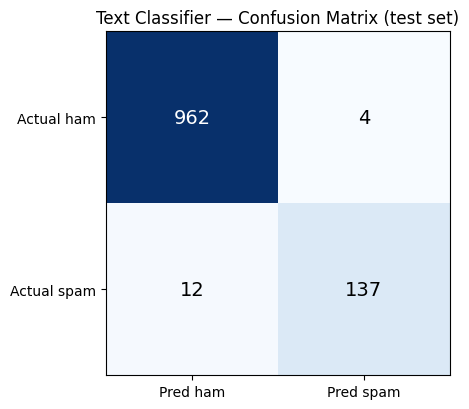

[[962   4]
 [ 12 137]]


In [9]:
cm = confusion_matrix(y_test, nn_pred)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred ham', 'Pred spam']); ax.set_yticklabels(['Actual ham', 'Actual spam'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_title('Text Classifier — Confusion Matrix (test set)')
plt.tight_layout(); plt.savefig('text_confusion_matrix.png', dpi=100); plt.show()
print(cm)

## 6. Error analysis — what does the model get wrong?

In [10]:
test_df = pd.DataFrame({'text': X_test, 'actual': y_test, 'pred': nn_pred, 'spam_prob': probs.round(3)})
fn = test_df[(test_df.actual == 1) & (test_df.pred == 0)]
fp = test_df[(test_df.actual == 0) & (test_df.pred == 1)]
pd.set_option('display.max_colwidth', 140)
print(f"Missed spam (false negatives): {len(fn)}")
display(fn.head(5)[['spam_prob', 'text']])
print(f"Legitimate messages flagged as spam (false positives): {len(fp)}")
display(fp.head(5)[['spam_prob', 'text']])

Missed spam (false negatives): 12


,spam_prob,text
196,0.035,ringtoneking 84484
219,0.064,Sorry I missed your call let's talk when you have the time. I'm on 07090201529
235,0.176,"Latest News! Police station toilet stolen, cops have nothing to go on!"
288,0.402,Bloomberg -Message center +447797706009 Why wait? Apply for your future http://careers. bloomberg.com
478,0.060,For sale - arsenal dartboard. Good condition but no doubles or trebles!


Legitimate messages flagged as spam (false positives): 4


,spam_prob,text
21,0.648,Realy sorry-i don't recognise this number and am now confused :) who r u please?!
82,0.538,"Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disaste..."
700,0.544,"We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us"
822,0.897,We are pleased to inform that your application for Airtel Broadband is processed successfully. Your installation will happen within 3 days.


## 7. Save the model and test it on new messages

In [11]:
model.save('spam_classifier.keras')
loaded = keras.models.load_model('spam_classifier.keras')

samples = [
    "WINNER!! You have been selected to receive a £900 prize reward. Call 09061701461 now to claim.",
    "Hey, are we still meeting for lunch at 1? I'm running 5 min late",
    "Free entry in our weekly competition! Text WIN to 80086 now",
    "Can you send me the notes from yesterday's lecture?",
]
for s, p in zip(samples, loaded.predict(tf.constant(samples), verbose=0).ravel()):
    print(f"{p:.3f} -> {'SPAM' if p >= 0.5 else 'ham '} | {s[:80]}")

0.999 -> SPAM | WINNER!! You have been selected to receive a £900 prize reward. Call 09061701461
0.005 -> ham  | Hey, are we still meeting for lunch at 1? I'm running 5 min late
0.993 -> SPAM | Free entry in our weekly competition! Text WIN to 80086 now
0.080 -> ham  | Can you send me the notes from yesterday's lecture?


**Results on the held-out test set (1,115 messages, 149 of them spam):**

| Model | Accuracy | Spam precision | Spam recall | Spam F1 |
|---|---|---|---|---|
| TF-IDF + Logistic Regression (baseline) | 0.9839 | 0.9517 | 0.9262 | 0.9388 |
| TensorFlow text classifier | 0.9857 | 0.9716 | 0.9195 | 0.9448 |

- **Accuracy is not the headline number here.** Always predicting "ham" would score 86.6% on this test set, so 98.6% means more once you look at the spam-class precision/recall: the TensorFlow model caught 137 of 149 spam messages (12 missed) and wrongly flagged 4 legitimate messages.
- **The neural network is roughly on par with the simple baseline, not clearly better.** It had fewer false alarms (4 vs. 7 by my calculation from the precision values) and one fewer spam caught, which is a difference of a few messages out of 1,115 on a single split and a single training run. I would not claim it beats the baseline; for a dataset this small and keyword-driven, TF-IDF + Logistic Regression is a strong, cheaper option.
- **Training:** early stopping (patience 3, best weights restored) ended training after 15 epochs, using a validation split carved from the training data; the test set was not used for any training or stopping decision. Class weights (about 0.58 for ham, 3.73 for spam) were used to offset the 87/13 imbalance. No hyperparameter tuning was done.

**Error analysis (from the output above):**
- *Missed spam* tends to be either very short (e.g. a bare ringtone keyword plus a number) or phrased like ordinary conversation around a premium-rate/contact number, so the model has little spam-like vocabulary to latch onto. Some of the missed items (a dartboard for sale, a joke "news" message) are ambiguous even to a human.
- *False alarms* were automated or commercial-sounding but legitimate-looking messages (a broadband application confirmation, a job-related notice), which resemble promotional text. Some dataset labels in this area may be debatable, so a few of these "errors" could be label noise rather than model mistakes.
- The four hand-written test messages at the end were all classified correctly, but that is a quick demo with n=4, not an evaluation.

**Limitations:** single random split and seed (no cross-validation); the dataset is an older SMS corpus, so patterns in modern spam (links, different scam types) may not be represented; the vocabulary is built from training text only, so unseen words are ignored.

**Next steps:** cross-validate both models, try a pretrained text encoder, and tune the decision threshold to trade off missed spam against false alarms.